<a href="https://colab.research.google.com/github/aronnaiqbal/220153_Logistic/blob/main/220153_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

In [47]:
df = pd.read_csv("/content/drive/MyDrive/ML_dataset/heart.csv")

In [48]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [49]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [50]:
df = df.dropna()

In [51]:
X = df.drop("target", axis=1)
y = df["target"]

In [52]:
X = pd.get_dummies(X, drop_first=True)

In [53]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [54]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [55]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [56]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [57]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [58]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("AUC Score:", auc)

Accuracy : 0.7922077922077922
Precision: 0.7956989247311828
Recall   : 0.8505747126436781
F1 Score : 0.8222222222222222
AUC Score: 0.9023846285812318


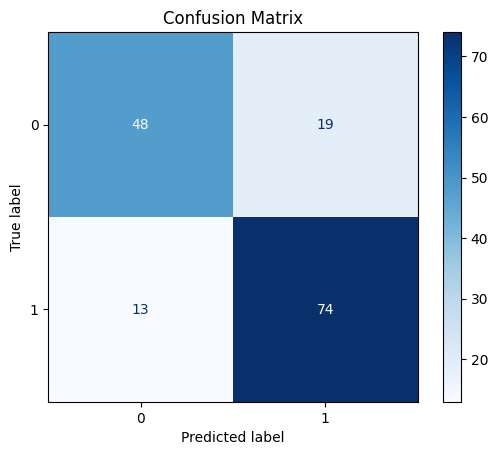

In [59]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

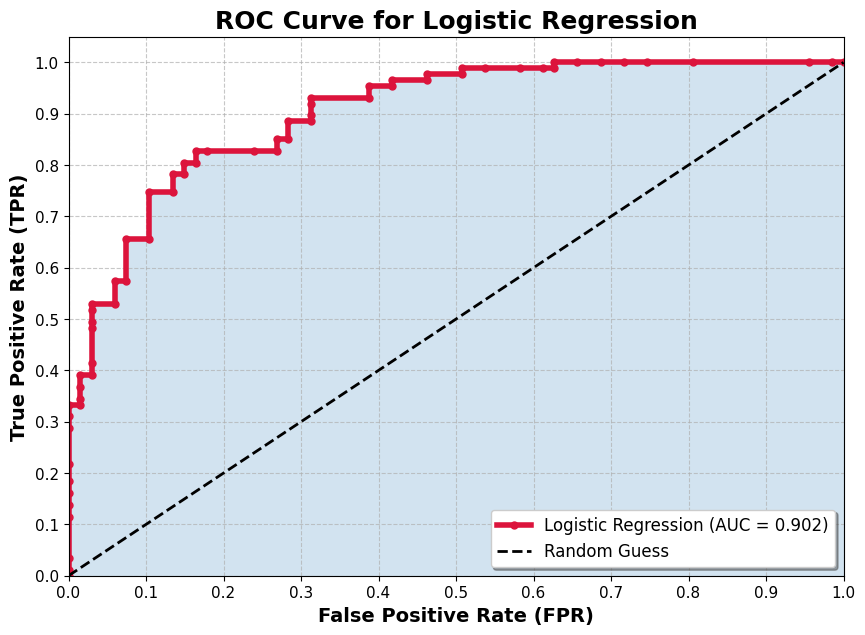

In [60]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(10,7))

plt.plot(
    fpr,
    tpr,
    color='crimson',
    linewidth=4,
    marker='o',
    markersize=5,
    label=f'Logistic Regression (AUC = {auc:.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    color='black',
    linestyle='--',
    linewidth=2,
    label='Random Guess'
)

plt.fill_between(fpr, tpr, alpha=0.2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xticks(np.arange(0, 1.1, 0.1), fontsize=11)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=11)

plt.xlabel("False Positive Rate (FPR)", fontsize=14, fontweight='bold')
plt.ylabel("True Positive Rate (TPR)", fontsize=14, fontweight='bold')

plt.title(
    "ROC Curve for Logistic Regression",
    fontsize=18,
    fontweight='bold'
)

plt.grid(True, linestyle='--', alpha=0.7)

plt.legend(
    loc='lower right',
    fontsize=12,
    frameon=True,
    shadow=True
)

plt.show()

In [61]:
results = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10],
    "Probability": y_prob[:10]
})

print(results)

   Actual  Predicted  Probability
0       0          0     0.110617
1       0          0     0.021045
2       0          0     0.008259
3       1          1     0.514103
4       1          1     0.730665
5       1          0     0.439487
6       1          1     0.873190
7       1          1     0.834520
8       0          0     0.005216
9       0          0     0.120548


In [62]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1025, 14)


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [64]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [65]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [66]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [67]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 723


In [68]:
print(df["target"].value_counts())

target
1    526
0    499
Name: count, dtype: int64


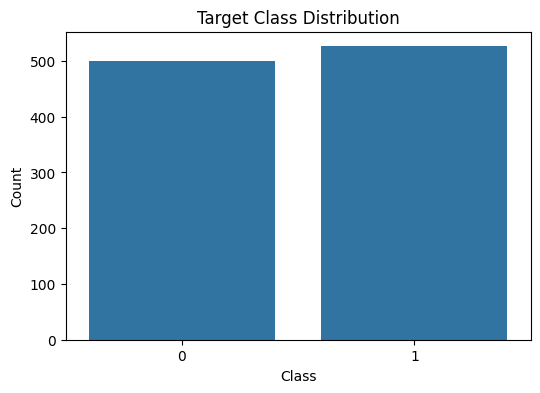

In [69]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x="target", data=df)

plt.title("Target Class Distribution")

plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [70]:
correlation = df.corr(numeric_only=True)

print(correlation)

               age       sex        cp  trestbps      chol       fbs  \
age       1.000000 -0.103240 -0.071966  0.271121  0.219823  0.121243   
sex      -0.103240  1.000000 -0.041119 -0.078974 -0.198258  0.027200   
cp       -0.071966 -0.041119  1.000000  0.038177 -0.081641  0.079294   
trestbps  0.271121 -0.078974  0.038177  1.000000  0.127977  0.181767   
chol      0.219823 -0.198258 -0.081641  0.127977  1.000000  0.026917   
fbs       0.121243  0.027200  0.079294  0.181767  0.026917  1.000000   
restecg  -0.132696 -0.055117  0.043581 -0.123794 -0.147410 -0.104051   
thalach  -0.390227 -0.049365  0.306839 -0.039264 -0.021772 -0.008866   
exang     0.088163  0.139157 -0.401513  0.061197  0.067382  0.049261   
oldpeak   0.208137  0.084687 -0.174733  0.187434  0.064880  0.010859   
slope    -0.169105 -0.026666  0.131633 -0.120445 -0.014248 -0.061902   
ca        0.271551  0.111729 -0.176206  0.104554  0.074259  0.137156   
thal      0.072297  0.198424 -0.163341  0.059276  0.100244 -0.04

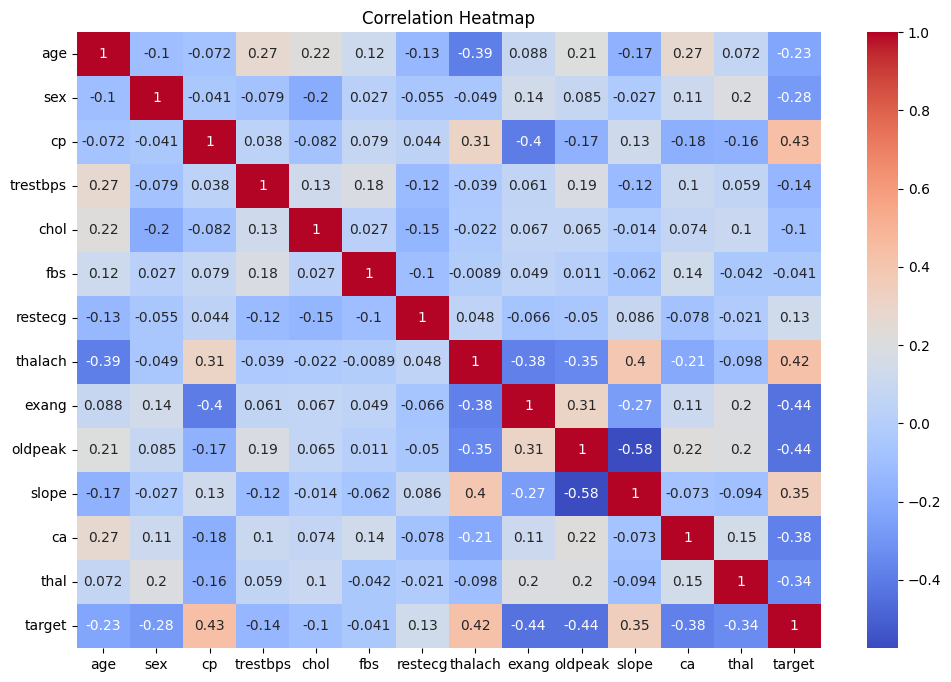

In [71]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

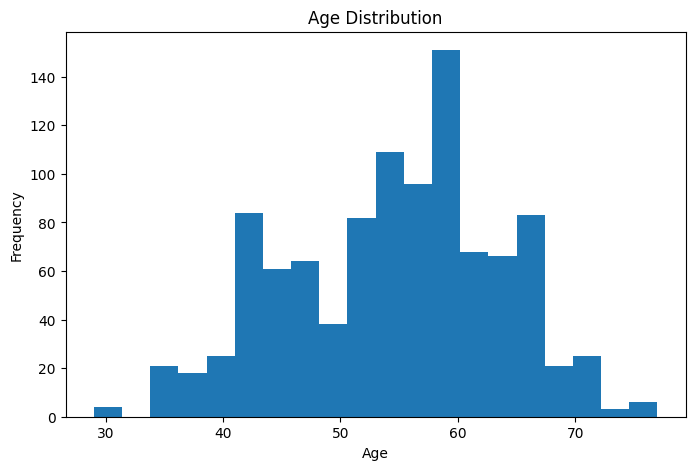

In [72]:
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=20)

plt.xlabel("Age")
plt.ylabel("Frequency")

plt.title("Age Distribution")

plt.show()

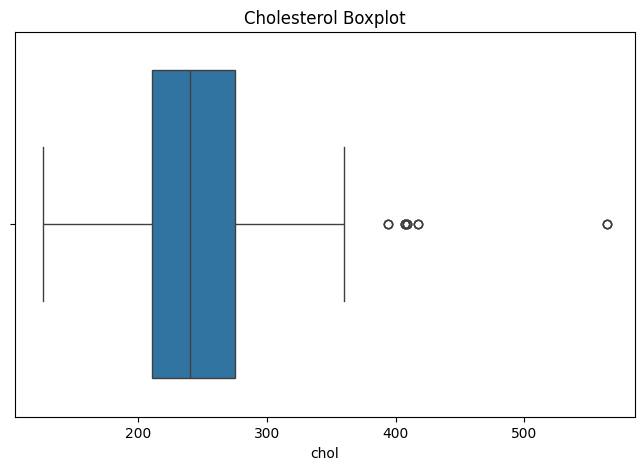

In [73]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["chol"])

plt.title("Cholesterol Boxplot")

plt.show()

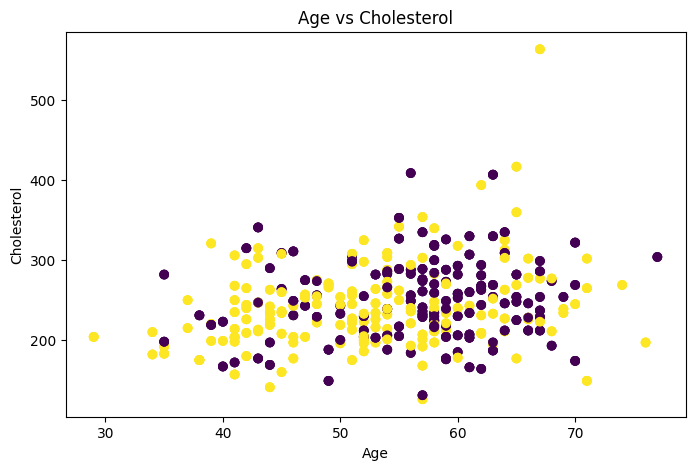

In [74]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["age"],
    df["chol"],
    c=df["target"]
)

plt.xlabel("Age")
plt.ylabel("Cholesterol")

plt.title("Age vs Cholesterol")

plt.show()